# Algoritmo DSP

En este notebook se encuentra el algoritmo original DSP aplicado sobre una red neuronal recurrente. Está todo el código disponible para modificar exclusivamente los hiperparámetros del modelo y el dataset que se quiere utilizar.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tqdm import tqdm
from graphviz import Digraph

from sklearn.decomposition import PCA

2025-08-27 12:24:37.392784: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-27 12:24:38.122600: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


## Funciones auxiliares

In [2]:
# Función utilizada para preparar el dataset a un batch size con un seq_len determinado.
# Esta función se encarga de preparar el dataset de forma correcta para poder entrenar
# una red stateful por batches

def transform_many_to_many(input_file, output_file, batch_size, seq_len):
    input_raw = open(input_file, 'r').read()
    output_raw = open(output_file, 'r').read()
    
    symbol2id = {}
    id2symbol = {}
    for i, symbol in enumerate(["a", "b", "$"]):
        symbol2id[symbol] = i
        id2symbol[i] = symbol
    
    inputs_raw = []
    outputs_raw = []
    window_size = len(input_raw)//batch_size
    min_len = window_size+1
    for i in range(batch_size):
        string = input_raw[i*window_size:(i+1)*window_size]        
        output = output_raw[i*window_size:(i+1)*window_size]
        output = output[string.find("$"):]
        string = string[string.find("$"):]
        if len(string) < min_len:
            min_len = len(string)
        inputs_raw.append(string)
        outputs_raw.append(output)
        
    dataset_x_temp = np.zeros((batch_size, min_len))
    dataset_y_temp = np.zeros((batch_size, min_len))
    for i in range(batch_size):
        x = [symbol2id[s] for s in inputs_raw[i][:min_len]]
        y = [int(s) for s in outputs_raw[i][:min_len]]
        dataset_x_temp[i] = x
        dataset_y_temp[i] = y
    
    # Aqui, todas las cadenas empiezan por $ y todas tienen la misma longitud
    # OK
    # Ahora, es necesario recolocar las cadenas por lotes para stateful=True
    num_ventanas = min_len//seq_len
    dataset_x = np.zeros((batch_size*num_ventanas, seq_len))
    dataset_y = np.zeros((batch_size*num_ventanas, seq_len))
    for i in range(num_ventanas):
        lote_x = dataset_x_temp[:, i*seq_len:(i+1)*seq_len]
        lote_y = dataset_y_temp[:, i*seq_len:(i+1)*seq_len]
        dataset_x[i*batch_size:(i+1)*batch_size] = lote_x
        dataset_y[i*batch_size:(i+1)*batch_size] = lote_y
    return dataset_x[:, :, None] == np.arange(3)[None, None, :], dataset_y

In [3]:
# Función utilizada para preparar el dataset a un batch size = 1 con un seq_len determinado.
# Esta función hace lo mismo que la anterior pero asumiendo que el batch_size = 1 para poder
# evaluar después del entrenamiento

def transform_many_to_many_1b(input_file, output_file, batch_size):
    input_raw = open(input_file, 'r').read()
    output_raw = open(output_file, 'r').read()
    
    symbol2id = {}
    id2symbol = {}
    for i, symbol in enumerate(["a", "b", "$"]):
        symbol2id[symbol] = i
        id2symbol[i] = symbol
    
    inputs_raw = []
    outputs_raw = []
    window_size = len(input_raw)//batch_size
    min_len = window_size+1
    for i in range(batch_size):
        string = input_raw[i*window_size:(i+1)*window_size]        
        output = output_raw[i*window_size:(i+1)*window_size]
        output = output[string.find("$"):]
        string = string[string.find("$"):]
        if len(string) < min_len:
            min_len = len(string)
        inputs_raw.append(string)
        outputs_raw.append(output)
        
    dataset_x_temp = np.zeros((batch_size, min_len))
    dataset_y_temp = np.zeros((batch_size, min_len))
    for i in range(batch_size):
        x = [symbol2id[s] for s in inputs_raw[i][:min_len]]
        y = [int(s) for s in outputs_raw[i][:min_len]]
        dataset_x_temp[i] = x
        dataset_y_temp[i] = y
        
    return dataset_x_temp[:, :, None] == np.arange(3)[None, None, :], dataset_y_temp

In [4]:
# Esta función dibuja el autómata a partir de un conjunto de estados, transiciones, estados
# de aceptación y el estado inicial

def crear_diagrama_de_estados(estados, transiciones, aceptacion, estado_inicial, draw_dollar=True):
    # Crear un objeto Digraph
    fsm = Digraph(format='png')
    
    # Configurar orientación hacia la derecha
    fsm.attr(rankdir='LR')
    
    fsm.node("", shape="none", label="")  # Nodo invisible para la flecha inicial
    fsm.edge("", str(estado_inicial))  # Flecha hacia el estado inicial

    # Añadir los estados (nodos)
    for estado in estados:
        if str(estado) == "-2":
            continue
        if estado in aceptacion:
            if True in aceptacion[estado] and False in aceptacion[estado]:
                if aceptacion[estado][True] > aceptacion[estado][False]:
                    fsm.node(str(estado), shape="doublecircle")
                else:
                    fsm.node(str(estado))
            elif True in aceptacion[estado]:
                fsm.node(str(estado), shape="doublecircle")
            else:
                fsm.node(str(estado))
        else:
            fsm.node(str(estado))

    # Añadir las transiciones (aristas)
    for origen in transiciones:
        if str(origen) == "-2":
            continue
        for simbolo in transiciones[origen]:
            if not draw_dollar and simbolo == "$":
                continue
            for destino in transiciones[origen][simbolo]:
                if str(destino) == "-2":
                    continue
                fsm.edge(str(origen), str(destino), label=simbolo)

    # Mostrar el grafo
    return fsm

In [5]:
# Este bloque de código tiene las funciones necesarias para pasar a determinista y minimizar un autómata

def _join_states(states, estado_aceptacion):
        state_names = [str(s) for s in states] # Copia
        state_names.sort()
        new_name = "+".join(state_names)
        return new_name, any(True in estado_aceptacion[s] for s in states)
    
def _process_symbol(current_states, symbol, tabla_transiciones):
    new_current_states = []
    for state in current_states:
        if state in tabla_transiciones:
            if symbol in tabla_transiciones[state]:
                for end_state in tabla_transiciones[state][symbol]:
                    new_current_states.append(end_state)
    return list(set(new_current_states))

def to_deterministic(tabla_transiciones, estado_aceptacion, initial_state=-1):
    """
        Esta función construye un Autómata Finito Determinista a partir del
          automata original.

        Args: No args

        Return:
            Un autómata finito determinista
    """
    # Initial state
    dfa_initial_state = str(initial_state)
    dfa_states = {dfa_initial_state}
    dfa_symbols = ["a", "b", "$"]
    dfa_transitions = {}
    dfa_estado_aceptacion = {dfa_initial_state: {True in estado_aceptacion[initial_state]: 1.0}}

    q = []
    q.append((dfa_initial_state, [initial_state]))
    while q:
        joint_state, current_states = q[0]
        q = q[1:]
        for s in dfa_symbols:
            current_states = current_states
            new_current_states = _process_symbol(current_states, s, tabla_transiciones)

            new_joint_state, new_aceptacion = _join_states(new_current_states, estado_aceptacion)
            if not new_joint_state in dfa_states:
                dfa_states.add(new_joint_state)
                dfa_estado_aceptacion[new_joint_state] = {new_aceptacion: 1.0}
                q.append((new_joint_state, new_current_states))

            if joint_state in dfa_transitions:
                if s in dfa_transitions:
                    dfa_transitions[joint_state][s][new_joint_state] = 1.0
                else:
                    dfa_transitions[joint_state][s] = {new_joint_state: 1.0}
            else:
                dfa_transitions[joint_state] = {s: {new_joint_state: 1.0}}
                
            

    return dfa_initial_state, dfa_states, dfa_transitions, dfa_estado_aceptacion

def _get_reachable_states(tabla_transiciones, estado_ini):
    pending = []
    pending.append(estado_ini)
    reachable_states = []

    while pending:
        state = pending[0]
        pending = pending[1:]
        if state not in reachable_states:
            reachable_states.append(state)
            for symbol in tabla_transiciones[state]:
                end_state = list(tabla_transiciones[state][symbol].keys())[0]
                pending.append(end_state)
    return reachable_states

def _assign_eq_classes(old_eq_classes, reachable_states, tabla_transiciones):
    def _state_same_transitions(s1, s2):
        for symbol in ["a", "b", "$"]:
            eq_class1 = []
            eq_class2 = []
            for end_state in tabla_transiciones[s1][symbol]:
                eq_class1.append(old_eq_classes[end_state])
            for end_state in tabla_transiciones[s2][symbol]:
                eq_class2.append(old_eq_classes[end_state])

            if eq_class1 != eq_class2:
                return False
        return True

    current_eq_classes = {s: -1 for s in reachable_states}
    next_eq_class = 0
    states = list(current_eq_classes.keys())
    for i, state in enumerate(states):
        if current_eq_classes[state] == -1:
            current_eq_classes[state] = next_eq_class

            for j in range(i, len(states)):
                if (current_eq_classes[states[j]] == -1 and
                    old_eq_classes[state] == old_eq_classes[states[j]] and
                    _state_same_transitions(state, states[j])):
                        current_eq_classes[states[j]] = next_eq_class
            next_eq_class += 1
    return current_eq_classes, next_eq_class

def minimize(estados, tabla_transiciones, estado_aceptacion, estado_ini):
        """
            Esta función minimiza un Autómata Finito Determinista"

            Args: No args

            Return:
                Un autómata finito determinista mínimo
        """

        reachable_states = _get_reachable_states(tabla_transiciones, estado_ini)
        old_eq_classes = {s: -1 for s in reachable_states}
        current_eq_classes = {}
        for s in reachable_states:
            current_eq_classes[s] = 1 if s in estado_aceptacion and True in estado_aceptacion[s] else 0

        while current_eq_classes != old_eq_classes:
            old_eq_classes = current_eq_classes
            current_eq_classes, n_classes = _assign_eq_classes(old_eq_classes, reachable_states, tabla_transiciones)

        nuevos_estados = []        
        nuevo_estado_aceptacion = {}
        nueva_tabla_transiciones = {}

        for state, value in current_eq_classes.items():
            new_state = str(value)
            new_state_aceptacion = estado_aceptacion[state]
            if new_state not in nuevos_estados:
                nuevos_estados.append(new_state)
                nuevo_estado_aceptacion[new_state] = new_state_aceptacion


        for state_old, value in current_eq_classes.items():
            start_state = nuevos_estados[value]
            for symbol in ["a", "b", "$"]:
                end_state = list(tabla_transiciones[state_old][symbol].keys())[0]

                end_state = nuevos_estados[current_eq_classes[end_state]]
                if start_state in nueva_tabla_transiciones:
                    if symbol not in nueva_tabla_transiciones[start_state]:
                        nueva_tabla_transiciones[start_state][symbol] = {end_state: 1.0}
                else:
                    nueva_tabla_transiciones[start_state] = {symbol: {end_state: 1.0}}

        return nuevos_estados, nueva_tabla_transiciones, nuevo_estado_aceptacion, current_eq_classes[estado_ini], current_eq_classes

In [7]:
# Función de construcción del modelo

def build_model(units, batch_size=1, input_dim=3, l1reg=0.0, optimizer="Adam", use_stateful=True):
    if not use_stateful:
        input_layer = tf.keras.Input(batch_shape=(1, None, input_dim))
        stateful = False
    else:
        input_layer = tf.keras.Input(batch_shape=(batch_size, None, input_dim))
        stateful = True
    rec_layer = tf.keras.layers.SimpleRNN(units, return_sequences=True, 
                                          stateful=stateful,
                                          kernel_regularizer=tf.keras.regularizers.l1(l1reg),
                                          recurrent_regularizer=tf.keras.regularizers.l1(l1reg)
                                         )(input_layer)
    output_layer = tf.keras.layers.Dense(2, activation="softmax",
                                         kernel_regularizer=tf.keras.regularizers.l1(l1reg)
                                        )(rec_layer)
    
    model = tf.keras.Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer=optimizer, loss=tf.keras.losses.SparseCategoricalCrossentropy(reduction="sum"), metrics=["accuracy"])
    
    model_rec = tf.keras.Model(inputs=input_layer, outputs=rec_layer)
    return model, model_rec

## Descarga de datos

Se descargan los datos de Github directamente.

In [26]:
seq_len = 25
batch_size = 20

path = "https://raw.githubusercontent.com/christianolivamoya/tesis-contribuciones-xai-dl/refs/heads/main/dataset/tomita/"
problema = "paridad"

input_file = problema + "_train_x.txt"
output_file = problema + "_train_y.txt"
try:
    dataset_x_train, dataset_y_train = transform_many_to_many(input_file, output_file, batch_size, seq_len)
except:
    !wget $path"train/"$input_file
    !wget $path"train/"$output_file
    dataset_x_train, dataset_y_train = transform_many_to_many(input_file, output_file, batch_size, seq_len)
print(dataset_x_train.shape, dataset_y_train.shape)
dataset_x_train_b1, dataset_y_train_b1 = transform_many_to_many_1b(input_file, output_file, 1)
print(dataset_x_train_b1.shape, dataset_y_train_b1.shape)

input_file = problema + "_cadenasLargas_x.txt"
output_file = problema + "_cadenasLargas_y.txt"
try:
    dataset_x_long, dataset_y_long = transform_many_to_many_1b(input_file, output_file, 1)
except:
    !wget $path"test/"$input_file
    !wget $path"test/"$output_file
    dataset_x_long, dataset_y_long = transform_many_to_many_1b(input_file, output_file, 1)
print (dataset_x_long.shape, dataset_y_long.shape)

input_file = problema + "_extremo_muchasA_x.txt"
output_file = problema + "_extremo_muchasA_y.txt"
try:
    dataset_x_allas, dataset_y_allas = transform_many_to_many_1b(input_file, output_file, 1)
except:
    !wget $path"test/"$input_file
    !wget $path"test/"$output_file
    dataset_x_allas, dataset_y_allas = transform_many_to_many_1b(input_file, output_file, 1)
print (dataset_x_allas.shape, dataset_y_allas.shape)

input_file = problema + "_extremo_muchasB_x.txt"
output_file = problema + "_extremo_muchasB_y.txt"
try:
    dataset_x_allbs, dataset_y_allbs = transform_many_to_many_1b(input_file, output_file, 1)
except:
    !wget $path"test/"$input_file
    !wget $path"test/"$output_file
    dataset_x_allbs, dataset_y_allbs = transform_many_to_many_1b(input_file, output_file, 1)
print (dataset_x_allbs.shape, dataset_y_allbs.shape)

input_file = problema + "_testGrande_x.txt"
output_file = problema + "_testGrande_y.txt"
try:
    dataset_x_big, dataset_y_big = transform_many_to_many_1b(input_file, output_file, 1)
except:
    !wget $path"test/"$input_file
    !wget $path"test/"$output_file
    dataset_x_big, dataset_y_big = transform_many_to_many_1b(input_file, output_file, 1)
print (dataset_x_big.shape, dataset_y_big.shape)

--2025-08-27 12:29:17--  https://raw.githubusercontent.com/christianolivamoya/tesis-contribuciones-xai-dl/refs/heads/main/dataset/tomita/train/paridad_train_x.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 50001 (49K) [text/plain]
Saving to: ‘paridad_train_x.txt’

paridad_train_x.txt 100%[===================>]  48,83K  --.-KB/s    in 0,002s  

2025-08-27 12:29:17 (27,0 MB/s) - ‘paridad_train_x.txt’ saved [50001/50001]

--2025-08-27 12:29:17--  https://raw.githubusercontent.com/christianolivamoya/tesis-contribuciones-xai-dl/refs/heads/main/dataset/tomita/train/paridad_train_y.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubuser

## Entrenamiento del modelo

In [27]:
with tf.device('/CPU:0'):
    hidden_size=10
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
    model, model_rec = build_model(hidden_size, batch_size, optimizer=optimizer)
    model.summary()
    
    n_epochs=50
    for epoch in range(n_epochs):
        model.reset_states()
        model.fit(dataset_x_train, dataset_y_train, shuffle=False, batch_size=batch_size)

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(20, None, 3)]           0         
                                                                 
 simple_rnn_2 (SimpleRNN)    (20, None, 10)            140       
                                                                 
 dense_2 (Dense)             (20, None, 2)             22        
                                                                 
Total params: 162 (648.00 Byte)
Trainable params: 162 (648.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
97/97 [==============================] - 0s 3ms/step - loss: 0.3056 - accuracy: 1.0000


In [28]:
model.save_weights("training")
model_rec.save_weights("training_REC")
model, model_rec = build_model(hidden_size, use_stateful=False)
model.load_weights("training")
model_rec.load_weights("training_REC")
model.summary()

Model: "model_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(1, None, 3)]            0         
                                                                 
 simple_rnn_3 (SimpleRNN)    (1, None, 10)             140       
                                                                 
 dense_3 (Dense)             (1, None, 2)              22        
                                                                 
Total params: 162 (648.00 Byte)
Trainable params: 162 (648.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## Evaluación del modelo

In [29]:
print(" > Train dataset:")
model.evaluate(dataset_x_train_b1, dataset_y_train_b1, batch_size=1)
print(" > Big dataset:")
model.evaluate(dataset_x_big, dataset_y_big, batch_size=1)
print(" > Long dataset:")
model.evaluate(dataset_x_long, dataset_y_long, batch_size=1)
print(" > All as dataset:")
model.evaluate(dataset_x_allas, dataset_y_allas, batch_size=1)
print(" > All bs dataset:")
model.evaluate(dataset_x_allbs, dataset_y_allbs, batch_size=1)

 > Train dataset:
1/1 [==============================] - 3s 3s/step - loss: 28.9481 - accuracy: 1.0000
 > Big dataset:
1/1 [==============================] - 7s 7s/step - loss: 58.0384 - accuracy: 1.0000
 > Long dataset:
1/1 [==============================] - 1s 1s/step - loss: 11.5800 - accuracy: 1.0000
 > All as dataset:
1/1 [==============================] - 1s 1s/step - loss: 10.7328 - accuracy: 1.0000
 > All bs dataset:
1/1 [==============================] - 1s 1s/step - loss: 6.4859 - accuracy: 1.0000


[6.4859209060668945, 1.0]

## Análisis y algoritmo DSP

In [30]:
hs = np.concatenate((model_rec.predict(dataset_x_train_b1, batch_size=1)))
ys = np.concatenate((dataset_y_train_b1))
print(hs.shape, ys.shape)

1/1 [==============================] - 3s 3s/step
(50001, 10) (50001,)


In [31]:
pca = PCA(n_components=2)
pca.fit(hs)
hs_2d = pca.transform(hs)

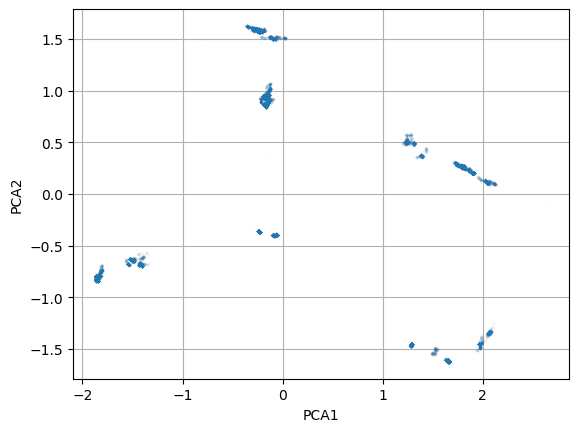

In [32]:
plt.grid()
plt.plot(hs_2d[:, 0], hs_2d[:, 1], '.', alpha=0.01, markersize=3)

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

### Paso 1: Clustering del espacio de estados interno

In [33]:
from sklearn.cluster import KMeans
K = 10
km = KMeans(K, n_init="auto")
km.fit(hs)
clusters = km.predict(hs)

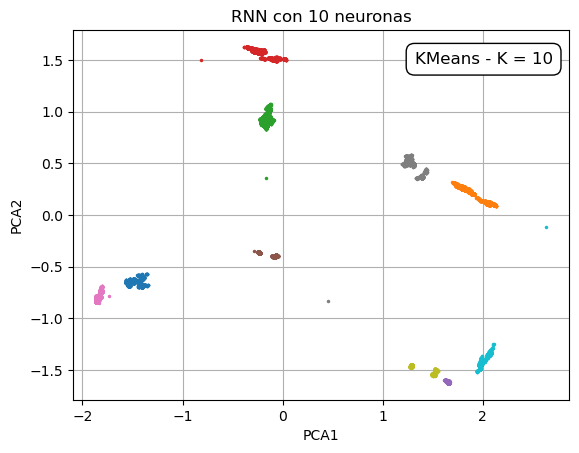

In [34]:
plt.grid()
for c in np.unique(clusters):
    plt.plot(hs_2d[clusters==c, 0], hs_2d[clusters==c, 1], '.', alpha=1, markersize=3)
    
plt.title("RNN con "+str(hidden_size)+" neuronas")
    
plt.text(
    hs_2d[:, 0].max() * (0.4 if K==6 else 0.5),  # Coordenada x
    hs_2d[:, 1].max() * 0.9,  # Coordenada y
    "KMeans - K = "+str(K),  # Texto
    fontsize=12,  # Tamaño de la fuente
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5')  # Recuadro
)

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

### Paso 2: Estracción de la tabla de transiciones

In [35]:
input_file = problema + "_train_x.txt"
text_x = open(input_file, 'r').read()

In [36]:
tabla_transiciones = {}
estado_aceptacion = {}
for i in tqdm(range(len(clusters))):
    simbolo = text_x[i]
    aceptar = ys[i]
    if i == 0:
        estado_ini = -1
    else:
        estado_ini = clusters[i-1]
    estado_aceptar = ys[i]
    estado_fin = clusters[i]
    if estado_fin in estado_aceptacion:
        if estado_aceptar in estado_aceptacion[estado_fin]:
            estado_aceptacion[estado_fin][estado_aceptar == 1] += 1
        else:
            estado_aceptacion[estado_fin][estado_aceptar == 1] = 1
    else:
        estado_aceptacion[estado_fin] = {estado_aceptar == 1: 1}
    if estado_ini in tabla_transiciones:
        if simbolo in tabla_transiciones[estado_ini]:
            if estado_fin in tabla_transiciones[estado_ini][simbolo]:
                tabla_transiciones[estado_ini][simbolo][estado_fin] += 1
            else:
                tabla_transiciones[estado_ini][simbolo][estado_fin] = 1
        else:
            tabla_transiciones[estado_ini][simbolo] = {estado_fin: 1}
    else:
        tabla_transiciones[estado_ini] = {simbolo: {estado_fin: 1}}

100%|█████████████████████████████████| 50001/50001 [00:00<00:00, 366197.99it/s]


In [37]:
# Las transiciones pueden ser no deterministas, luego se gestionan llamando a la función
# to_deterministic

for estado_ini in tabla_transiciones:
    for simbolo in tabla_transiciones[estado_ini]:
        suma = sum(tabla_transiciones[estado_ini][simbolo].values())
        for estado_fin in tabla_transiciones[estado_ini][simbolo]:
            tabla_transiciones[estado_ini][simbolo][estado_fin] /= suma
tabla_transiciones

{-1: {'$': {7: 1.0}},
 7: {'b': {9: 0.0014245014245014246, 1: 0.9985754985754985},
  'a': {3: 1.0},
  '$': {7: 1.0}},
 9: {'a': {3: 1.0}, 'b': {1: 1.0}, '$': {7: 1.0}},
 3: {'b': {2: 1.0}, 'a': {6: 1.0}, '$': {0: 1.0}},
 2: {'a': {6: 1.0}, 'b': {2: 1.0}, '$': {0: 1.0}},
 6: {'a': {5: 1.0}, 'b': {4: 1.0}, '$': {8: 1.0}},
 5: {'a': {6: 1.0}, 'b': {2: 1.0}, '$': {0: 1.0}},
 4: {'b': {1: 1.0}, 'a': {3: 1.0}, '$': {7: 1.0}},
 1: {'a': {3: 1.0}, '$': {7: 1.0}, 'b': {1: 1.0}},
 8: {'a': {3: 1.0}, 'b': {1: 1.0}, '$': {7: 1.0}},
 0: {'b': {9: 1.0}, 'a': {5: 1.0}, '$': {8: 1.0}}}

In [38]:
# Si en esta celda salen estados no deterministas en su salida, el autómata resultante
# fallará, ya que no se están considerando estados con salida probabilistica

for estado_ini in estado_aceptacion:
    suma = sum(estado_aceptacion[estado_ini].values())
    for estado_aceptar in estado_aceptacion[estado_ini]:
        estado_aceptacion[estado_ini][estado_aceptar] /= suma
estado_aceptacion

{7: {True: 1.0},
 9: {True: 1.0},
 3: {False: 1.0},
 2: {False: 1.0},
 6: {True: 1.0},
 5: {False: 1.0},
 4: {True: 1.0},
 1: {True: 1.0},
 8: {True: 1.0},
 0: {True: 1.0}}

In [39]:
# Se añade a las transiciones un estado sumidero para simplificar la tabla y tenerla
# completa
tabla_transiciones[-2] = {'$': {-1: 1.0}, "a": {-2: 1.0}, "b": {-2: 1.0}}

for simbolo in ["a", "b", "$"]:
    for estado_ini in tabla_transiciones:
        if simbolo not in tabla_transiciones[estado_ini]:
            tabla_transiciones[estado_ini][simbolo] = {-2: 1.0}
tabla_transiciones

{-1: {'$': {7: 1.0}, 'a': {-2: 1.0}, 'b': {-2: 1.0}},
 7: {'b': {9: 0.0014245014245014246, 1: 0.9985754985754985},
  'a': {3: 1.0},
  '$': {7: 1.0}},
 9: {'a': {3: 1.0}, 'b': {1: 1.0}, '$': {7: 1.0}},
 3: {'b': {2: 1.0}, 'a': {6: 1.0}, '$': {0: 1.0}},
 2: {'a': {6: 1.0}, 'b': {2: 1.0}, '$': {0: 1.0}},
 6: {'a': {5: 1.0}, 'b': {4: 1.0}, '$': {8: 1.0}},
 5: {'a': {6: 1.0}, 'b': {2: 1.0}, '$': {0: 1.0}},
 4: {'b': {1: 1.0}, 'a': {3: 1.0}, '$': {7: 1.0}},
 1: {'a': {3: 1.0}, '$': {7: 1.0}, 'b': {1: 1.0}},
 8: {'a': {3: 1.0}, 'b': {1: 1.0}, '$': {7: 1.0}},
 0: {'b': {9: 1.0}, 'a': {5: 1.0}, '$': {8: 1.0}},
 -2: {'$': {-1: 1.0}, 'a': {-2: 1.0}, 'b': {-2: 1.0}}}

In [40]:
for estado in tabla_transiciones:
    if estado not in estado_aceptacion:
        estado_aceptacion[estado] = {False: 1.0}
estado_aceptacion

{7: {True: 1.0},
 9: {True: 1.0},
 3: {False: 1.0},
 2: {False: 1.0},
 6: {True: 1.0},
 5: {False: 1.0},
 4: {True: 1.0},
 1: {True: 1.0},
 8: {True: 1.0},
 0: {True: 1.0},
 -1: {False: 1.0},
 -2: {False: 1.0}}

### Paso 3: Construir el autómata

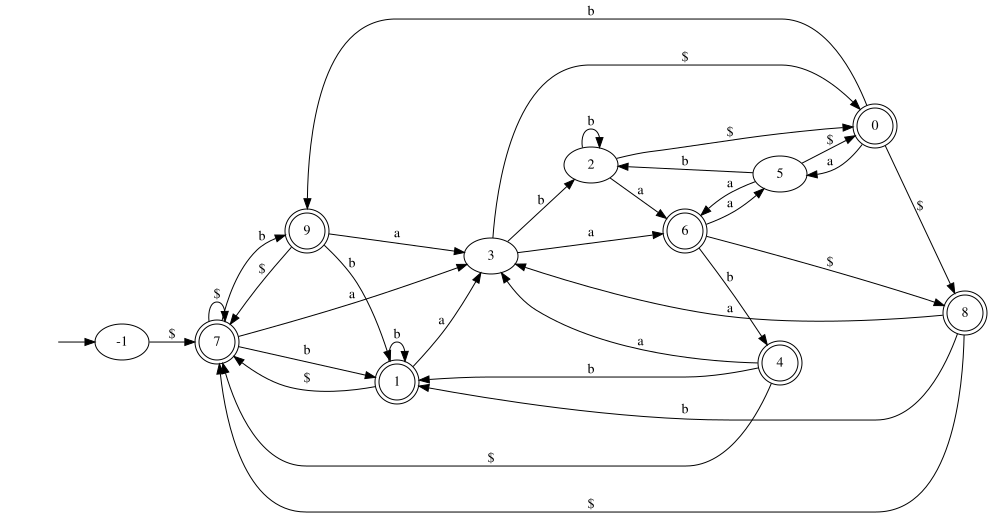

In [41]:
estados = list(tabla_transiciones.keys())
crear_diagrama_de_estados(estados, tabla_transiciones, estado_aceptacion, -1)

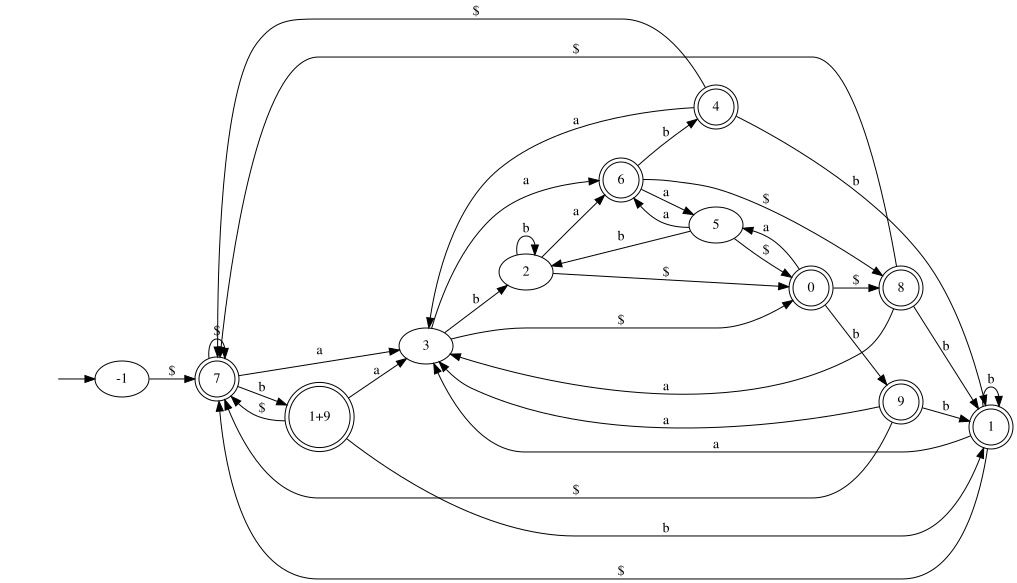

In [42]:
## Pasamos el autómata a determinista
(estado_ini, 
 estados_dfa,
 tabla_transiciones_dfa, 
 estado_aceptacion_dfa) = to_deterministic(tabla_transiciones, estado_aceptacion)

crear_diagrama_de_estados(estados_dfa, tabla_transiciones_dfa, estado_aceptacion_dfa, estado_ini)

### Paso 4: Minimización del autómata

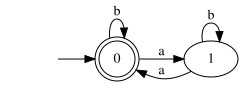

In [43]:
(nuevos_estados, 
 nueva_tabla_transiciones, 
 nuevo_estado_aceptacion, 
 nuevo_estado_ini,
 eq_classes) = minimize(estados_dfa, 
                        tabla_transiciones_dfa, 
                        estado_aceptacion_dfa, 
                        estado_ini=list(tabla_transiciones_dfa[estado_ini]['$'].keys())[0])

crear_diagrama_de_estados(nuevos_estados, 
                          nueva_tabla_transiciones, 
                          nuevo_estado_aceptacion, 
                          estado_inicial=nuevo_estado_ini,
                          draw_dollar=False)